# Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
print(LogisticRegression)

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load data
df = pd.read_csv("../data/diabetes_dataset/diabetic_data.csv")

# Replace ? with NaN
df = df.replace("?", np.nan)

# Drop columns with too many missing values / not useful
df = df.drop(columns=["weight", "payer_code", "medical_specialty",
                      "encounter_id", "patient_nbr"])

# Target
y = df["readmitted"]
X = df.drop(columns=["readmitted"])

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Logistic regression pipeline
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000
    ))
])

# Split data: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split train+val into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)
# This gives 60% train, 20% val, 20% test overall

# Hyperparameter tuning on validation through GridSearchCV
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs"],
    "classifier__penalty": ["l2"]
}

grid_search = GridSearchCV(
    log_reg_pipeline,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

from sklearn.metrics import f1_score

best_model = grid_search.best_estimator_

val_preds = best_model.predict(X_val)
print("Best parameters:", grid_search.best_params_)
print("Validation Accuracy:", accuracy_score(y_val, val_preds))

test_preds = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_preds))
print("Baseline Macro F1:", f1_score(y_test, test_preds, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_test, test_preds))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, test_preds))

C:\Users\15103\AppData\Local\Temp\ipykernel_12656\2423337876.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns
C:\Users\15103\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

Best parameters: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Validation Accuracy: 0.5786861887682405
Test Accuracy: 0.5754151518129115
Baseline Macro F1: 0.361606829333464

Classification Report:

              precision    recall  f1-score   support

         <30       0.31      0.01      0.01      2272
         >30       0.50      0.28      0.36      7109
          NO       0.59      0.88      0.71     10973

    accuracy                           0.58     20354
   macro avg       0.47      0.39      0.36     20354
weighted avg       0.53      0.58      0.51     20354


Confusion Matrix:

[[  16  720 1536]
 [  24 1999 5086]
 [  12 1264 9697]]


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

balanced_log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=0.01,
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced"
    ))
])

balanced_log_reg_pipeline.fit(X_train, y_train)

balanced_val_preds = balanced_log_reg_pipeline.predict(X_val)
balanced_test_preds = balanced_log_reg_pipeline.predict(X_test)

print("Balanced Validation Accuracy:", accuracy_score(y_val, balanced_val_preds))
print("Balanced Test Accuracy:", accuracy_score(y_test, balanced_test_preds))
print("Balanced Macro F1:", f1_score(y_test, balanced_test_preds, average="macro"))
print("\nBalanced Classification Report:\n")
print(classification_report(y_test, balanced_test_preds))
print("\nBalanced Confusion Matrix:\n")
print(confusion_matrix(y_test, balanced_test_preds))

C:\Users\15103\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Balanced Validation Accuracy: 0.500712425686631
Balanced Test Accuracy: 0.4929252235432839
Balanced Macro F1: 0.4253536268070961

Balanced Classification Report:

              precision    recall  f1-score   support

         <30       0.19      0.39      0.25      2272
         >30       0.46      0.34      0.39      7109
          NO       0.66      0.61      0.63     10973

    accuracy                           0.49     20354
   macro avg       0.43      0.45      0.43     20354
weighted avg       0.53      0.49      0.51     20354


Balanced Confusion Matrix:

[[ 895  632  745]
 [1926 2421 2762]
 [1997 2259 6717]]


In [29]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])

0

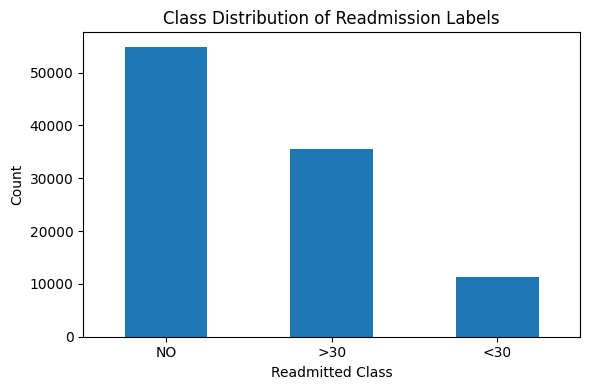

In [30]:
import matplotlib.pyplot as plt

class_counts = y.value_counts()

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution of Readmission Labels")
plt.xlabel("Readmitted Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

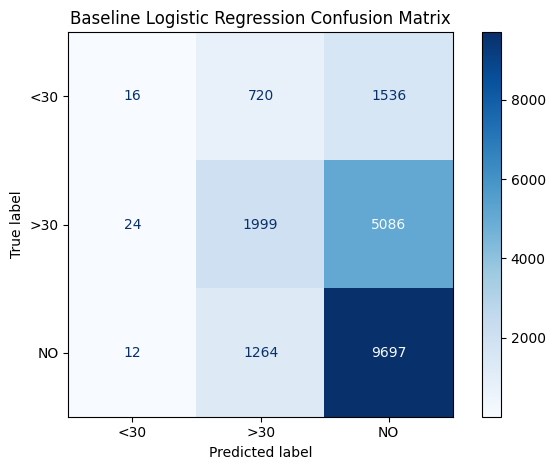

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels = ["<30", ">30", "NO"]

cm_baseline = confusion_matrix(y_test, test_preds, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=labels)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Baseline Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

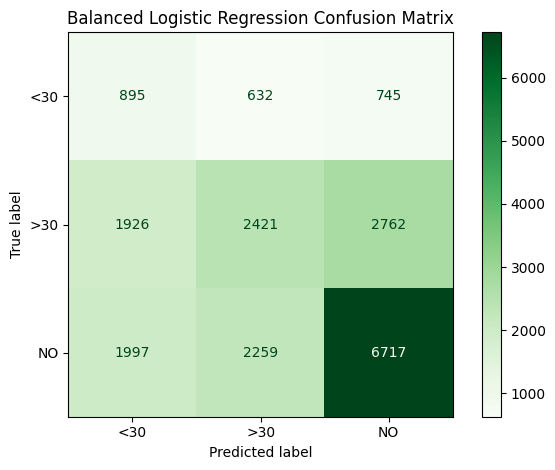

In [32]:
cm_balanced = confusion_matrix(y_test, balanced_test_preds, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=labels)

plt.figure(figsize=(6,5))
disp.plot(cmap="Greens", values_format="d")
plt.title("Balanced Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

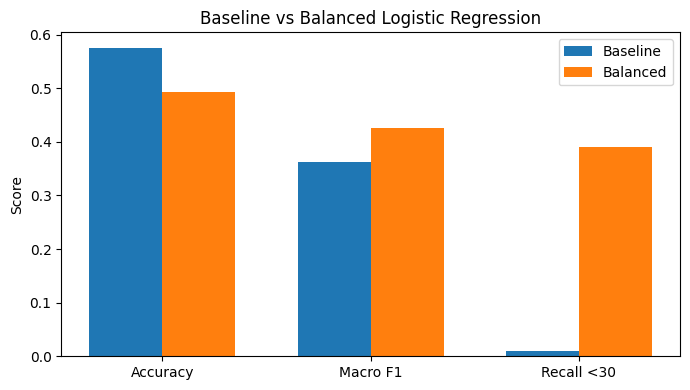

In [33]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Macro F1", "Recall <30"]
baseline_vals = [0.5754, 0.3616, 0.01]
balanced_vals = [0.4929, 0.4254, 0.39]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar([i - width/2 for i in x], baseline_vals, width=width, label="Baseline")
plt.bar([i + width/2 for i in x], balanced_vals, width=width, label="Balanced")
plt.xticks(list(x), metrics)
plt.ylabel("Score")
plt.title("Baseline vs Balanced Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()